In [1]:
import sys, os
sys.path.append('../MultiFishLSS/')
from headers import *
from twoPoint import *
from twoPointNoise import *
from classy import Class

import matplotlib.pyplot as plt

import matplotlib
from matplotlib.pyplot import rc
import matplotlib.font_manager

rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
rc('mathtext', **{'fontset':'cm'})
rc('text', usetex=True)
rc('legend',**{'fontsize':'18'})

matplotlib.rcParams['axes.linewidth'] = 3
matplotlib.rcParams['axes.labelsize'] = 30
matplotlib.rcParams['xtick.labelsize'] = 25 
matplotlib.rcParams['ytick.labelsize'] = 25
matplotlib.rcParams['legend.fontsize'] = 25
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.minor.size'] = 5
matplotlib.rcParams['xtick.major.width'] = 3
matplotlib.rcParams['ytick.major.width'] = 3
matplotlib.rcParams['xtick.minor.width'] = 1.5
matplotlib.rcParams['ytick.minor.width'] = 1.5
matplotlib.rcParams['axes.titlesize'] = 30
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

import os
os.environ["PATH"] += os.pathsep + "/usr/local/texlive/2020/bin/x86_64-darwin"

In [2]:
default_cosmo = {
        'output': 'tCl lCl mPk',
        'non linear':'halofit',
        'l_max_scalars': 4000,
        'lensing': 'yes',
        'P_k_max_h/Mpc': 2.,
        'z_pk': '0.0,1087',
        'A_s': 2.10732e-9,
        'n_s': 0.96824,
        'alpha_s': 0.,
        'h': 0.6736,
        'N_ur': 2.0328,
        'N_ncdm': 1,
        'm_ncdm': 0.06,
        'tau_reio': 0.0544,
        'omega_b': 0.02237,
        'omega_cdm': 0.1200,
        'Omega_k': 0.,
        'Omega_Lambda': 0.,
        'w0_fld':-1,
        'wa_fld':0}
cosmo = Class()
cosmo.set(default_cosmo)
cosmo.compute()
h = cosmo.h()

chi = lambda zz: cosmo.comoving_distance(zz)*h

## Compute WiggleSplit Forecast

In [3]:
fsky = 5000/41253 # 5000 deg2

# two redshift bins from z = 2.7 to 3.3
zmin, zmax = 2.7, 3.3
nbins = 2

# 2 galaxy samples 
# name, bias, number density as lists
samples=['ga','gb']
b = [lambda z: 2.5, lambda z: 3.5] 
n = [lambda z: 2e-4, lambda z: 2e-4]

# overlap between stochastic terms
# index 0 and 2 are auto-correlations, so they must be 1
# index 1 is the cross-correlation between the two samples, set to 0 by default for no overlap
fover=[1,0,1]

# experiment name and basedir
bd='./'

recon = 'wigglesplit'

bfn = 'multitracer_multifish_{}'.format(recon)

exp = experiment(zmin=zmin, zmax=zmax, nbins=nbins, fsky=fsky, b=b, n=n,samples=samples,fover=fover)
wsforecast = fisherForecast(experiment=exp,cosmo=cosmo,name=bfn,basedir=bd,ell=np.arange(10,3000,1), recon=recon, overwrite=True) 

Initialising fiducial Pk with recon = wigglesplit and self.recon = False
Finished computing fiducial Pk, setting self.recon = wigglesplit
Initialising fiducial Precon with recon = wigglesplit and self.recon = wigglesplit
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 2.5,2.5
sigmaS = 2.0 
 sigmaPar = 2.0589865986808547 
 sigmaPerp = 1.041709422916835 
 r = 0.543022468257405 
 ba = 2.5 
 bb = 2.5 
 f = 0.9765460054259624 
 alpha_parallel = 1.0 
 alpha_perp = 1.0 
 ap_deriv = False
Using simpson integration
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 2.5,3.5
sigmaS = 2.0 
 sigmaPar = 2.0098175677844634 
 sigmaPerp = 1.0168331838809543 
 r = 0.5300549780676733 
 ba = 2.5 
 bb = 3.5 
 f = 0.9765460054259624 
 alpha_parallel = 1.0 
 alpha_perp = 1.0 
 ap_deriv = False
Using simpson integration
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 3.5,3.5
sigmaS = 2.0 
 sigmaPar = 1.957548808199594 
 sigmaPerp = 0.9903886895755436 
 r = 0.516269987499637 
 ba = 3.5 
 bb = 3.5 
 f = 0.9765460054259624 
 alpha_parallel = 1.0 


In [4]:
basis = np.array(['alpha_parallel','alpha_perp','b', 'f'])

wsforecast.free_params = basis
wsforecast.compute_derivatives(overwrite=True) # will not overwrite unless specified

wsF = lambda i: wsforecast.gen_fisher(basis, 100, zbins=np.array([i]))
wsFs = np.array([wsF(i) for i in range(nbins)])

b, ba,bb = -1.0,2.5,2.5
WS ba,bb = 2.5,2.5
sigmaS = 2.0 
 sigmaPar = 2.0589865986808547 
 sigmaPerp = 1.041709422916835 
 r = 0.543022468257405 
 ba = 2.5 
 bb = 2.5 
 f = 0.9765460054259624 
 alpha_parallel = 1.0 
 alpha_perp = 1.0 
 ap_deriv = False
Using simpson integration
alpha_parallel in kwargs
alpha_parallel default_value = 1.0
b, ba,bb = -1.0,2.5,2.5
WS ba,bb = 2.5,2.5
sigmaS = 2.0 
 sigmaPar = 2.0589865986808547 
 sigmaPerp = 1.041709422916835 
 r = 0.543022468257405 
 ba = 2.5 
 bb = 2.5 
 f = 0.9765460054259624 
 alpha_parallel = 1.01 
 alpha_perp = 1.0 
 ap_deriv = True
Using simpson integration
b, ba,bb = -1.0,2.5,2.5
WS ba,bb = 2.5,2.5
sigmaS = 2.0 
 sigmaPar = 2.0589865986808547 
 sigmaPerp = 1.041709422916835 
 r = 0.543022468257405 
 ba = 2.5 
 bb = 2.5 
 f = 0.9765460054259624 
 alpha_parallel = 0.99 
 alpha_perp = 1.0 
 ap_deriv = True
Using simpson integration
b, ba,bb = -1.0,2.5,2.5
WS ba,bb = 2.5,2.5
sigmaS = 2.0 
 sigmaPar = 2.0589865986808547 
 sigmaPerp = 1.04

In [5]:
wsFinvs = [np.linalg.inv(wsFs[i]) for i in range(nbins)]
ws_sigma_a_par = np.array([np.sqrt(wsFinvs[i][0,0]) for i in range(nbins)])
ws_sigma_a_perp = np.array([np.sqrt(wsFinvs[i][1,1]) for i in range(nbins)])

print('Relative error on a_par:',ws_sigma_a_par)
print('Relative error on a_perp:',ws_sigma_a_perp)

Relative error on a_par: [0.00990383 0.01062597]
Relative error on a_perp: [0.00720528 0.00781523]


## Compute LPT Forecast

In [6]:
recon = 'LPT'

bfn = 'multitracer_multifish_{}'.format(recon)

lptforecast = fisherForecast(experiment=exp,cosmo=cosmo,name=bfn,basedir=bd, recon=recon, overwrite=True)

Initialising fiducial Pk with recon = LPT and self.recon = False
Finished computing fiducial Pk, setting self.recon = LPT
Initialising fiducial Precon with recon = LPT and self.recon = LPT
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 2.5,2.5
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 2.5,3.5
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 3.5,3.5
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 2.5,2.5
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 2.5,3.5
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 3.5,3.5
Finished computing fiducial Precon, setting self.recon = LPT


In [7]:
lptforecast.free_params = basis
lptforecast.compute_derivatives(overwrite=True) # will not overwrite unless specified

lptF = lambda i: lptforecast.gen_fisher(basis, 100,zbins=np.array([i]))
lptFs = np.array([lptF(i) for i in range(nbins)])

b, ba,bb = -1.0,2.5,2.5
WS ba,bb = 2.5,2.5
alpha_parallel in kwargs
alpha_parallel default_value = 1.0
b, ba,bb = -1.0,2.5,3.5
WS ba,bb = 2.5,3.5
alpha_parallel in kwargs
alpha_parallel default_value = 1.0
b, ba,bb = -1.0,3.5,3.5
WS ba,bb = 3.5,3.5
alpha_parallel in kwargs
alpha_parallel default_value = 1.0
b, ba,bb = -1.0,2.5,2.5
WS ba,bb = 2.5,2.5
alpha_perp in kwargs
alpha_perp default_value = 1.0
b, ba,bb = -1.0,2.5,3.5
WS ba,bb = 2.5,3.5
alpha_perp in kwargs
alpha_perp default_value = 1.0
b, ba,bb = -1.0,3.5,3.5
WS ba,bb = 3.5,3.5
alpha_perp in kwargs
alpha_perp default_value = 1.0
b, ba,bb = 2.5,-1.0,-1.0
WS ba,bb = 2.5,2.5
b in kwargs
b default_value = 2.5
b, ba,bb = 2.525,-1.0,-1.0
WS ba,bb = 2.525,2.525
b, ba,bb = 2.475,-1.0,-1.0
WS ba,bb = 2.475,2.475
b, ba,bb = 2.55,-1.0,-1.0
WS ba,bb = 2.55,2.55
b, ba,bb = 2.45,-1.0,-1.0
WS ba,bb = 2.45,2.45
b, ba,bb = -1.0,2.5,3.5
WS ba,bb = 2.5,3.5
ba in kwargs
ba default_value = 2.5
b, ba,bb = -1.0,2.525,3.5
WS ba,bb = 2.525,3.5
b, ba,bb

In [8]:
lptFinvs = [np.linalg.inv(lptFs[i]) for i in range(nbins)]
lpt_sigma_a_par = np.array([np.sqrt(lptFinvs[i][0,0]) for i in range(nbins)])
lpt_sigma_a_perp = np.array([np.sqrt(lptFinvs[i][1,1]) for i in range(nbins)])

print('Relative error on a_par:',lpt_sigma_a_par)
print('Relative error on a_perp:',lpt_sigma_a_perp)

Relative error on a_par: [0.01150979 0.01205125]
Relative error on a_perp: [0.00783463 0.00835328]


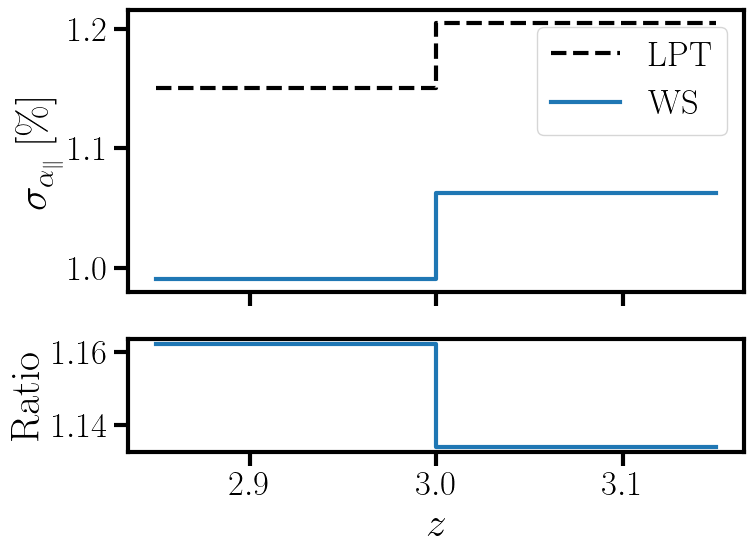

In [9]:
zs = exp.zcenters

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1]},  # Top is 2x taller
    figsize=(8, 6)
)

ax1.step(zs, 100*lpt_sigma_a_par, color='black', ls='--', lw=3, label=r'LPT', where='mid')
ax1.step(zs, 100*ws_sigma_a_par, ls='-', lw=3, label=r'WS', where='mid')

ax1.set_ylabel(r'$\sigma_{\alpha_\|} \; [\%]$')
ax1.legend()

ax2.step(zs, lpt_sigma_a_par/ws_sigma_a_par, lw=3, where='mid')
ax2.set_ylabel('Ratio')
ax2.set_xlabel(r'$z$')

plt.tight_layout()

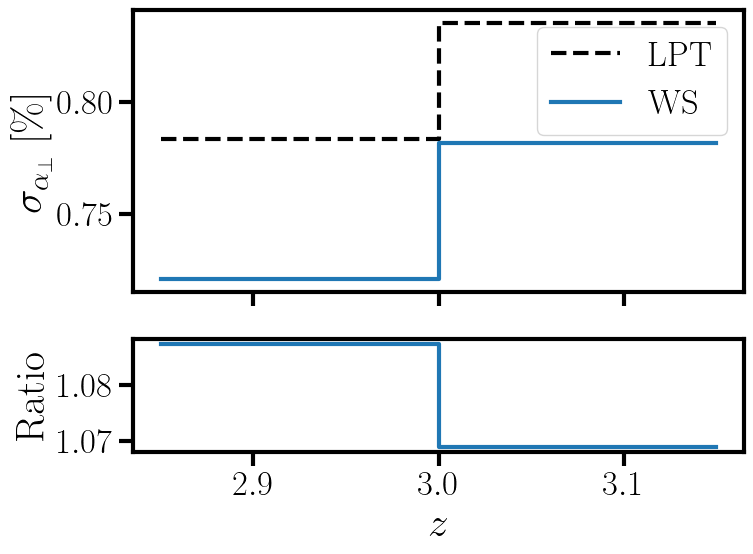

In [10]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1]},  # Top is 2x taller
    figsize=(8, 6)
)

ax1.step(zs, 100*lpt_sigma_a_perp, color='black', ls='--', lw=3, label=r'LPT', where='mid')
ax1.step(zs, 100*ws_sigma_a_perp, ls='-', lw=3, label=r'WS', where='mid')

ax1.set_ylabel(r'$\sigma_{\alpha_\perp} \; [\%]$')
ax1.legend()

ax2.step(zs, lpt_sigma_a_perp/ws_sigma_a_perp, lw=3, where='mid')
ax2.set_ylabel('Ratio')
ax2.set_xlabel(r'$z$')

plt.tight_layout()

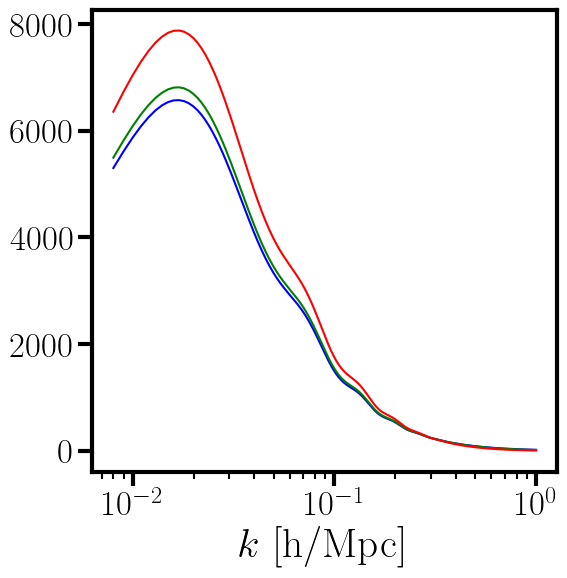

Pgaga_ba_285.txt


<Figure size 640x480 with 0 Axes>

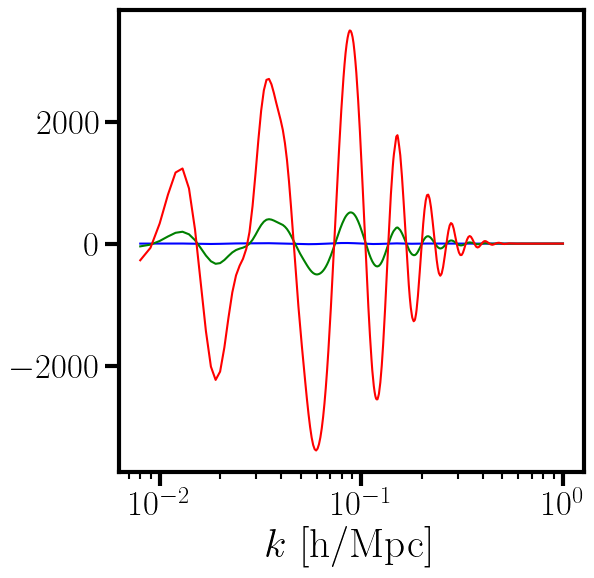

Pgbgb_alpha_parallel_285.txt


<Figure size 640x480 with 0 Axes>

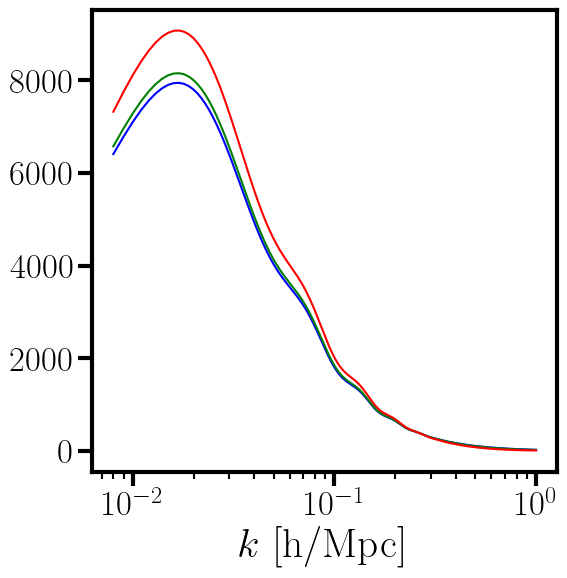

Pgagb_ba_315.txt


<Figure size 640x480 with 0 Axes>

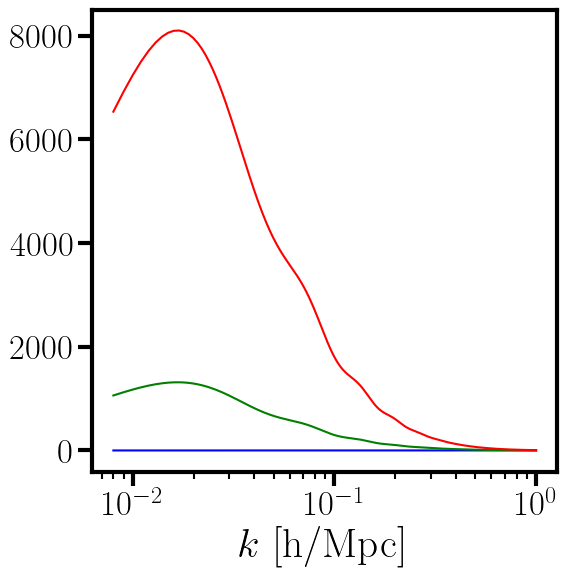

Pgagb_f_315.txt


<Figure size 640x480 with 0 Axes>

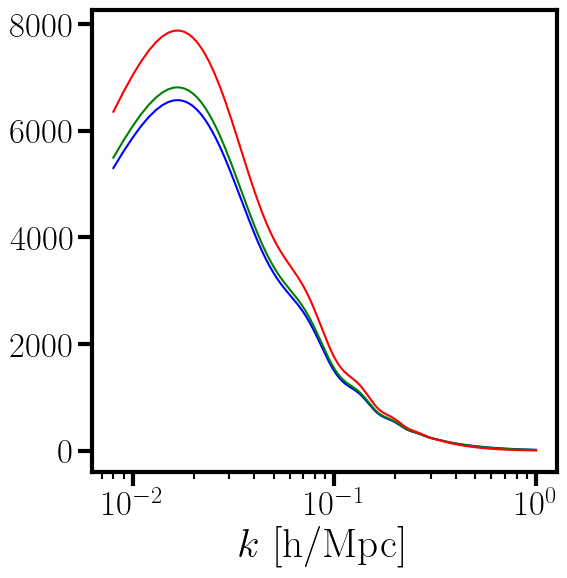

Pgagb_bgb_285.txt


<Figure size 640x480 with 0 Axes>

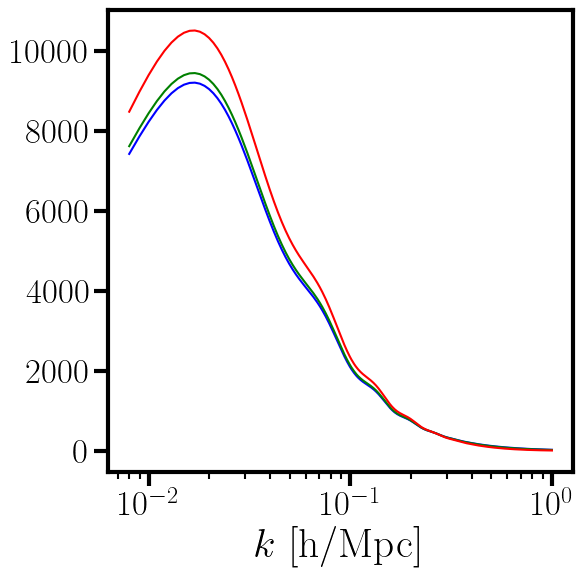

Pgbgb_ba_285.txt


<Figure size 640x480 with 0 Axes>

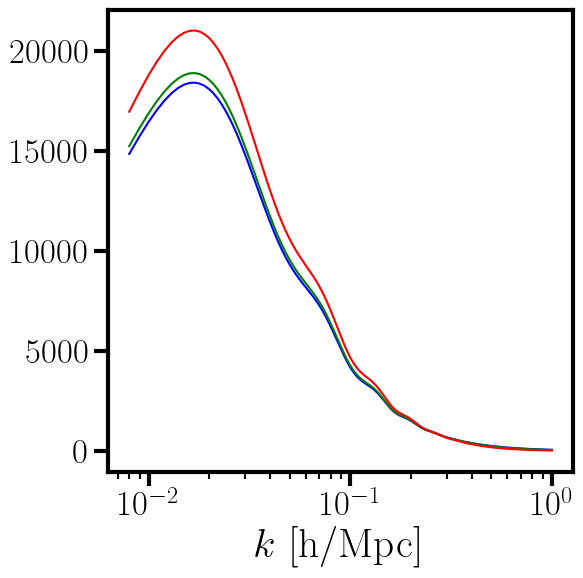

Pgbgb_bgb_285.txt


<Figure size 640x480 with 0 Axes>

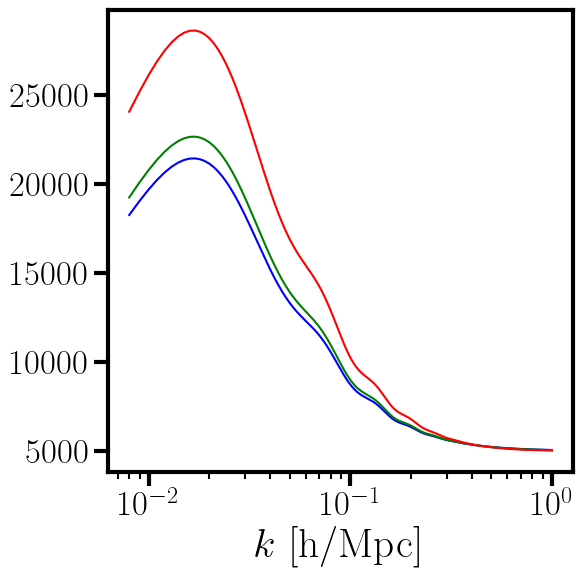

pfid_gaga_285.txt


<Figure size 640x480 with 0 Axes>

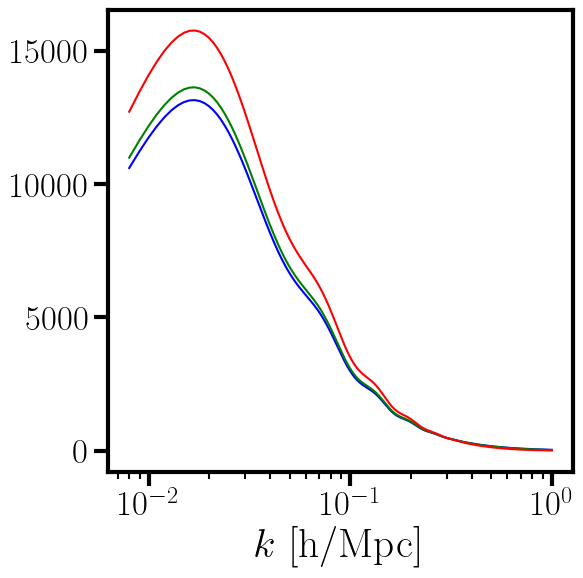

Pgaga_bga_285.txt


<Figure size 640x480 with 0 Axes>

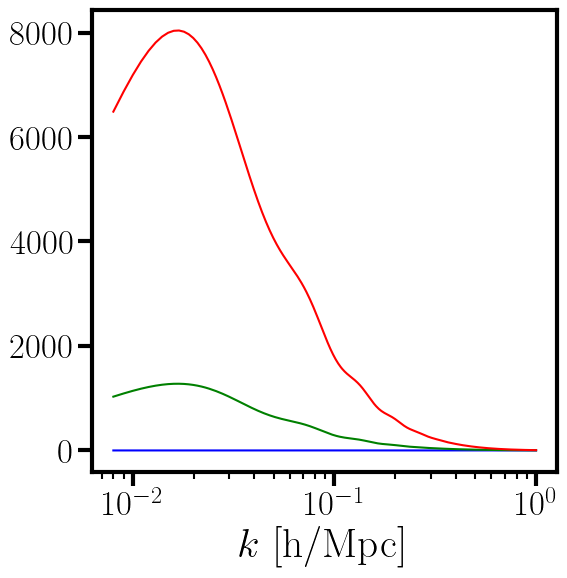

Pgaga_f_285.txt


<Figure size 640x480 with 0 Axes>

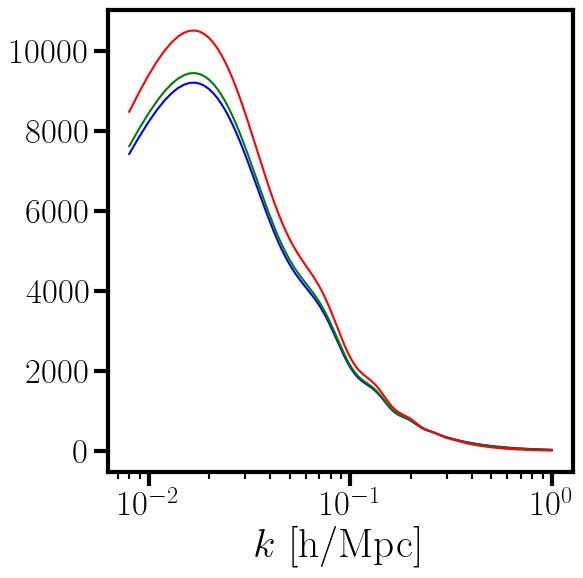

Pgagb_bga_285.txt


<Figure size 640x480 with 0 Axes>

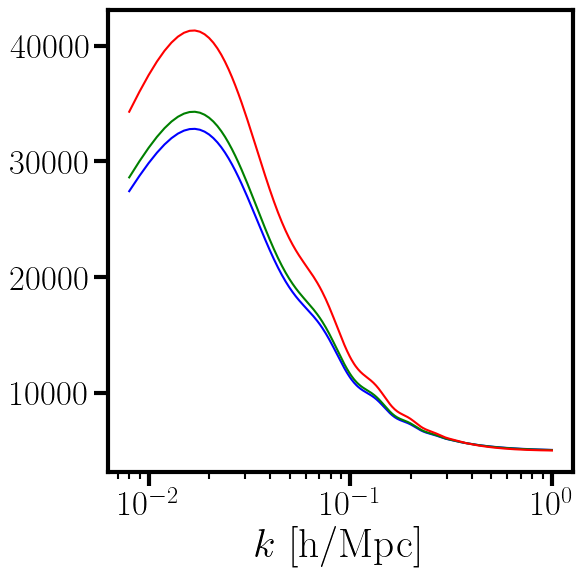

pfid_gbgb_315.txt


<Figure size 640x480 with 0 Axes>

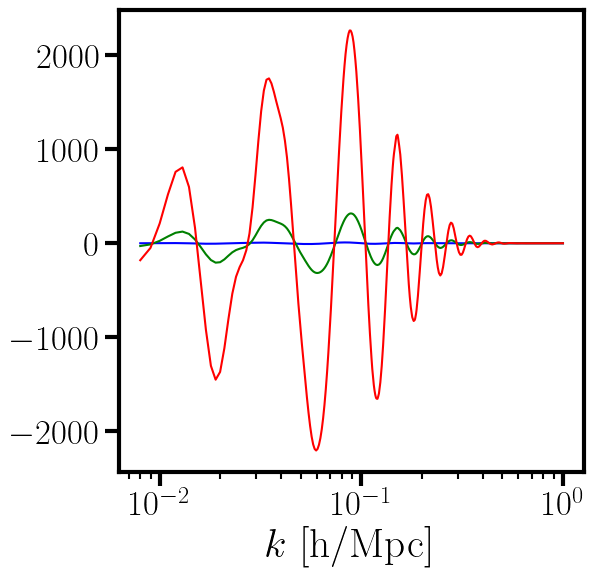

Pgagb_alpha_parallel_315.txt


<Figure size 640x480 with 0 Axes>

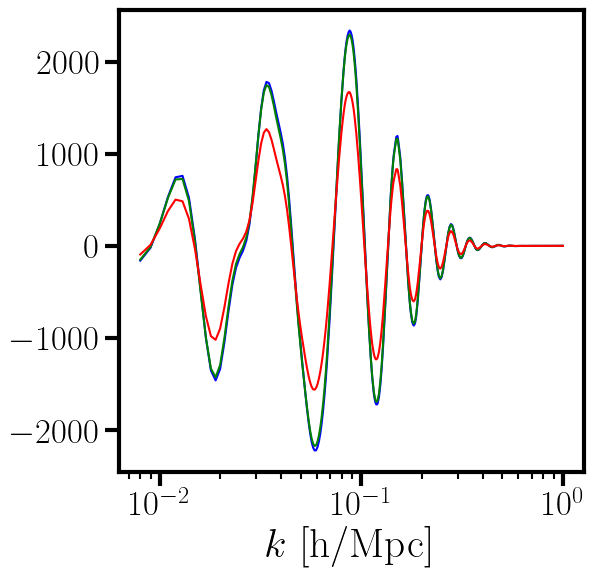

Pgaga_alpha_perp_315.txt


<Figure size 640x480 with 0 Axes>

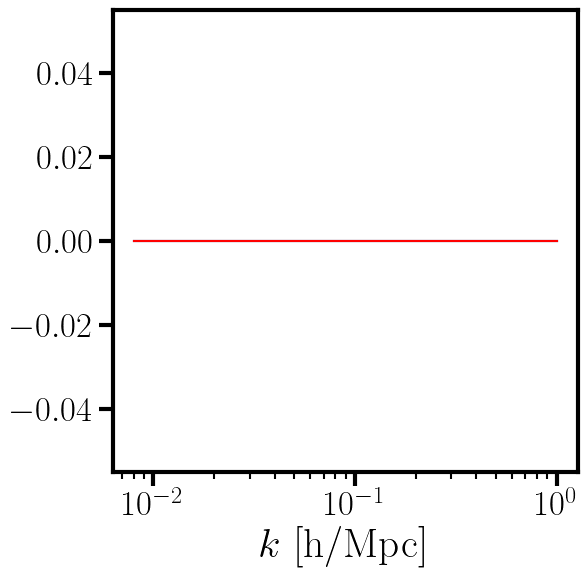

Pgaga_bgb_285.txt


<Figure size 640x480 with 0 Axes>

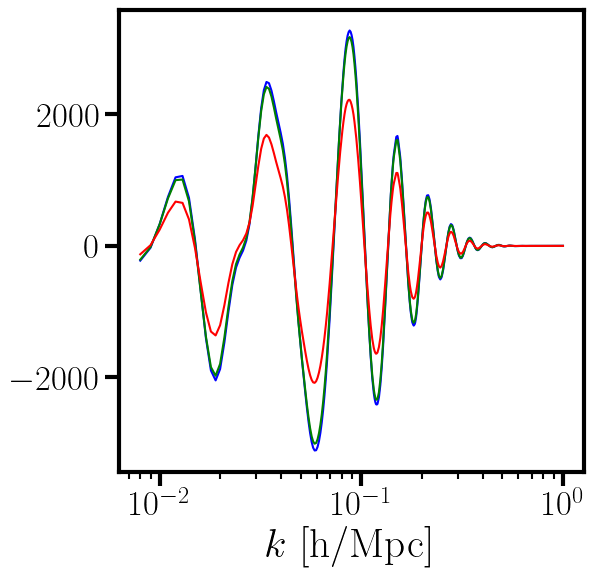

Pgagb_alpha_perp_315.txt


<Figure size 640x480 with 0 Axes>

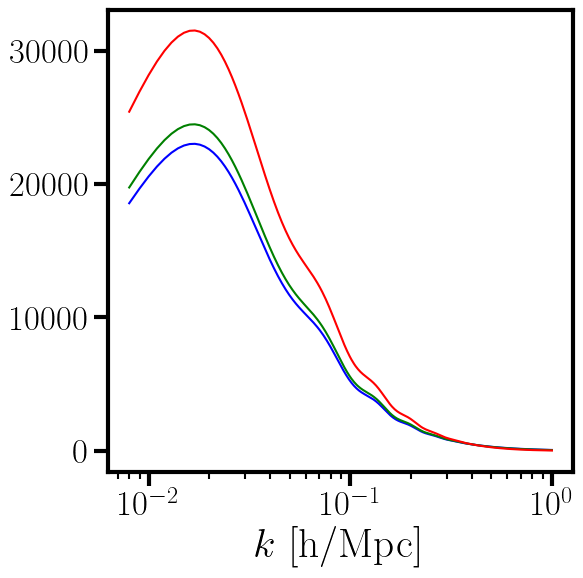

pfid_gagb_285.txt


<Figure size 640x480 with 0 Axes>

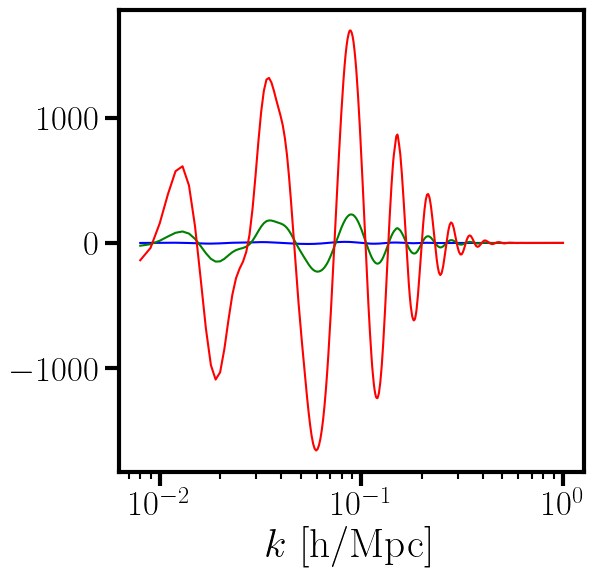

Pgaga_alpha_parallel_315.txt


<Figure size 640x480 with 0 Axes>

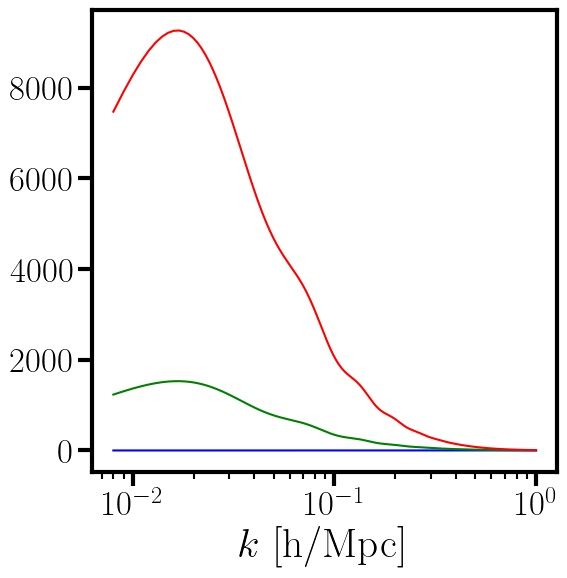

Pgbgb_f_315.txt


<Figure size 640x480 with 0 Axes>

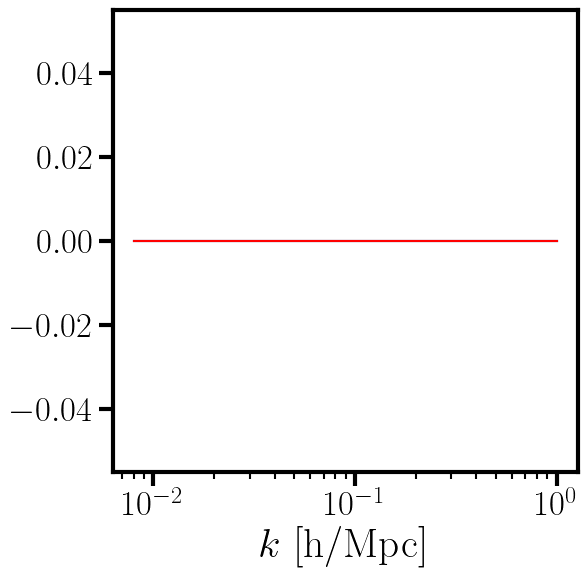

Pgbgb_bga_285.txt


<Figure size 640x480 with 0 Axes>

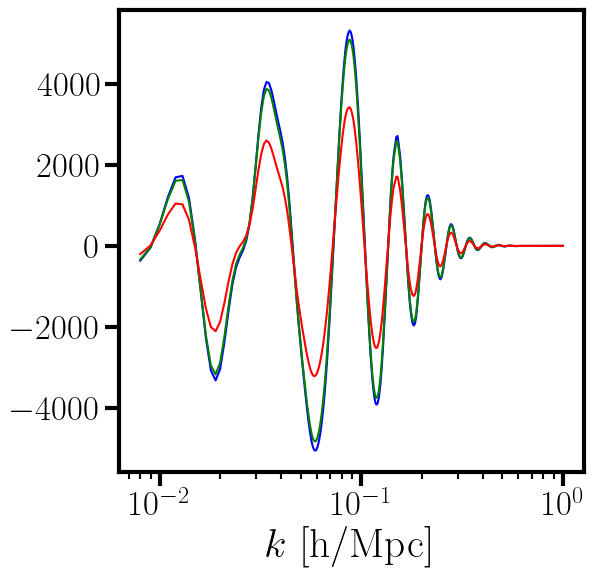

Pgbgb_alpha_perp_285.txt


<Figure size 640x480 with 0 Axes>

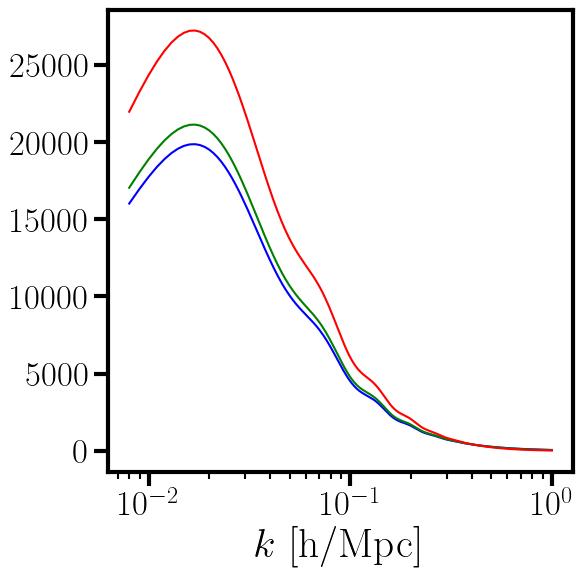

pfid_gagb_315.txt


<Figure size 640x480 with 0 Axes>

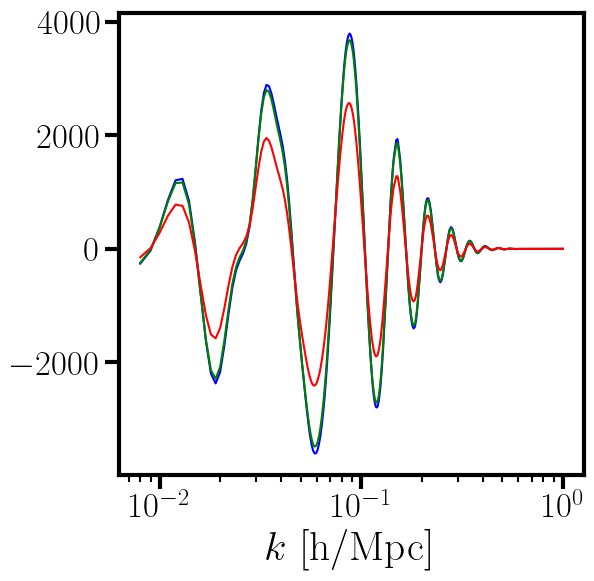

Pgagb_alpha_perp_285.txt


<Figure size 640x480 with 0 Axes>

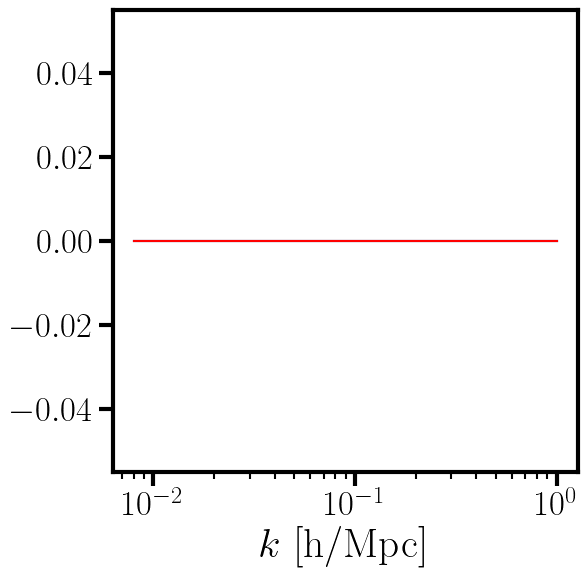

Pgaga_bgb_315.txt


<Figure size 640x480 with 0 Axes>

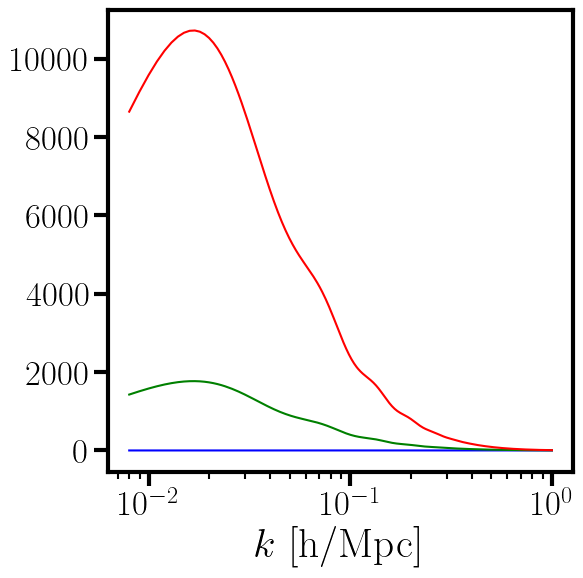

Pgbgb_f_285.txt


<Figure size 640x480 with 0 Axes>

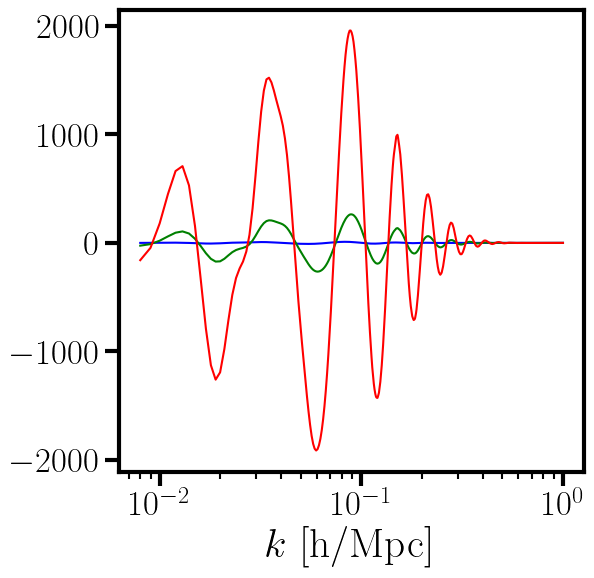

Pgaga_alpha_parallel_285.txt


<Figure size 640x480 with 0 Axes>

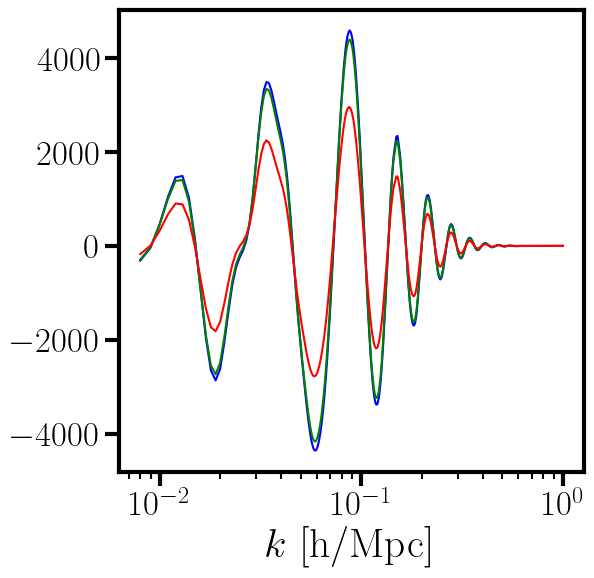

Pgbgb_alpha_perp_315.txt


<Figure size 640x480 with 0 Axes>

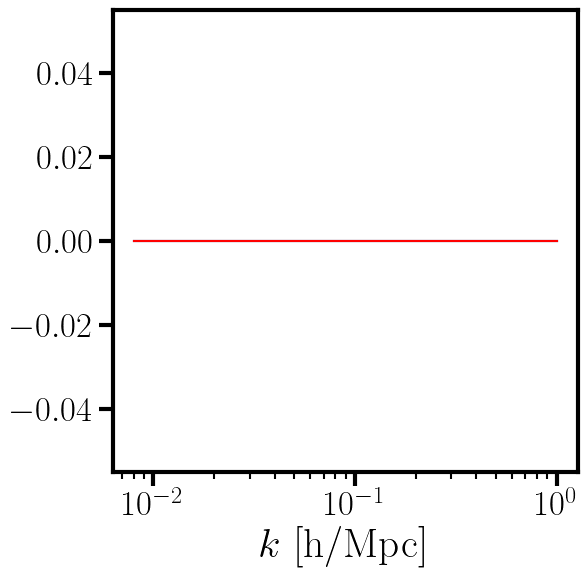

Pgbgb_bga_315.txt


<Figure size 640x480 with 0 Axes>

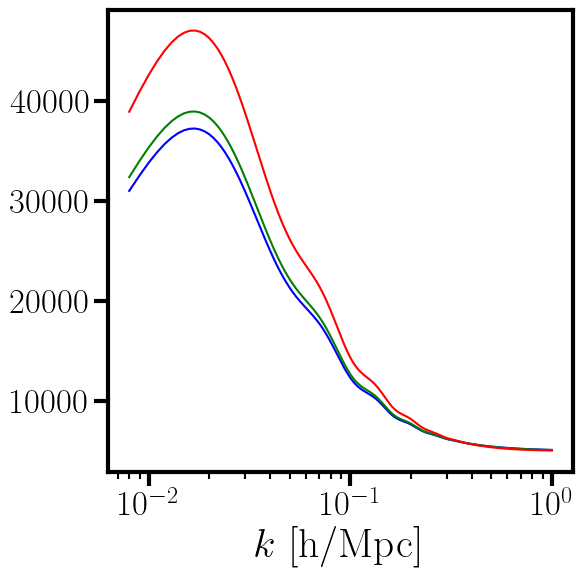

pfid_gbgb_285.txt


<Figure size 640x480 with 0 Axes>

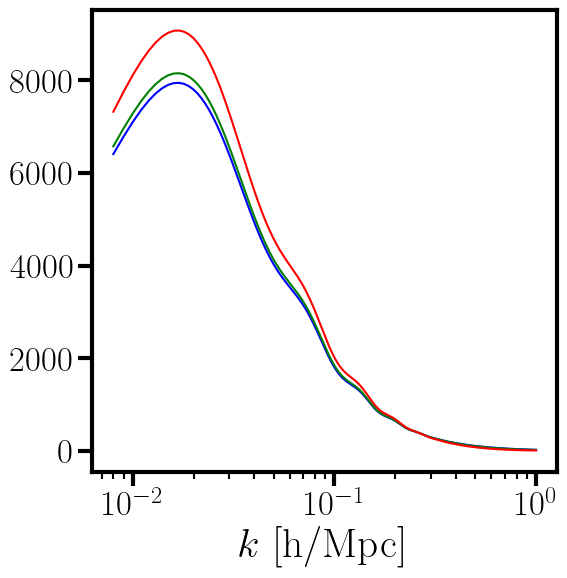

Pgagb_bga_315.txt


<Figure size 640x480 with 0 Axes>

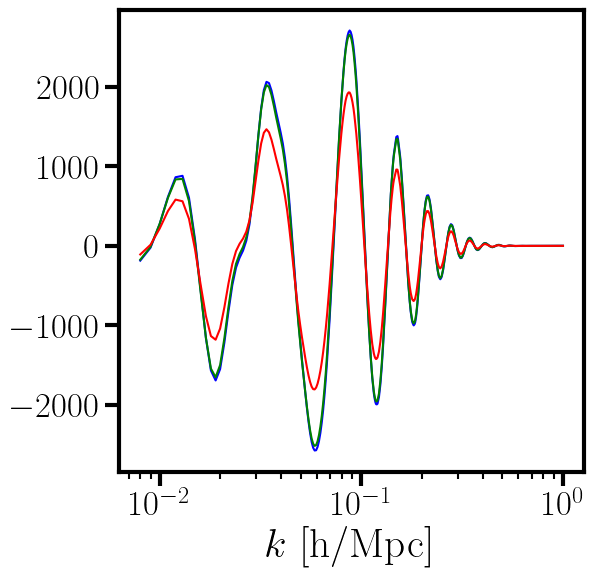

Pgaga_alpha_perp_285.txt


<Figure size 640x480 with 0 Axes>

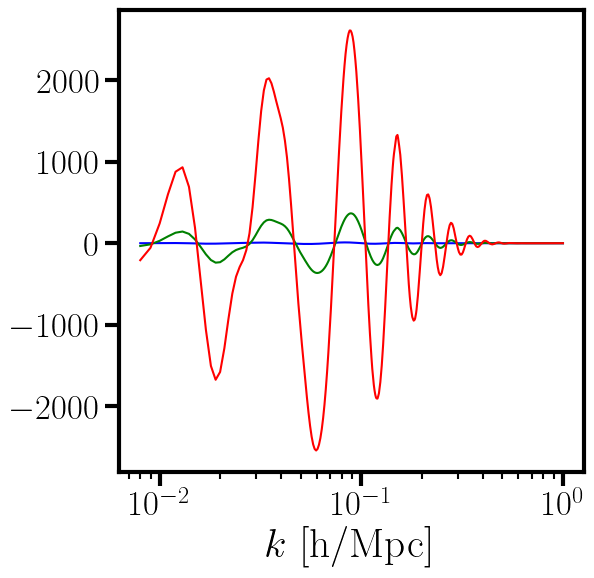

Pgagb_alpha_parallel_285.txt


<Figure size 640x480 with 0 Axes>

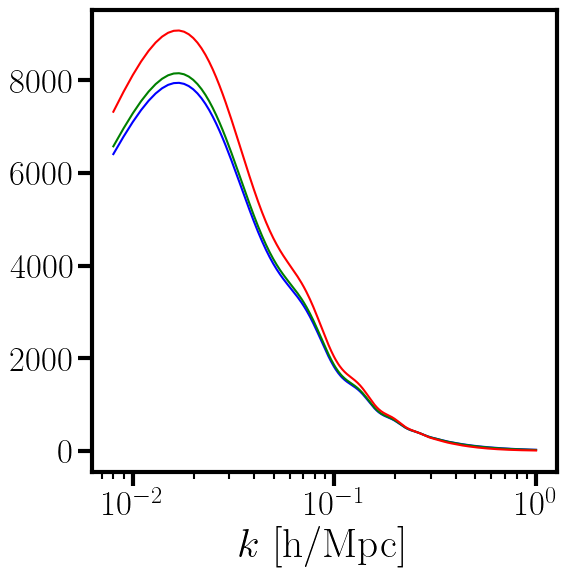

Pgbgb_ba_315.txt


<Figure size 640x480 with 0 Axes>

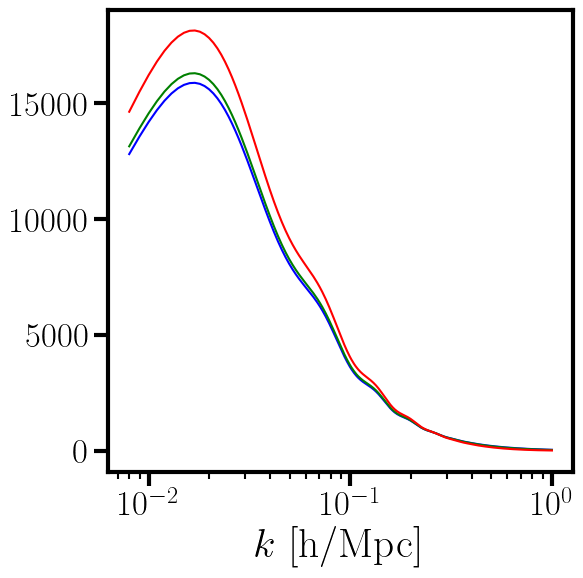

Pgbgb_bgb_315.txt


<Figure size 640x480 with 0 Axes>

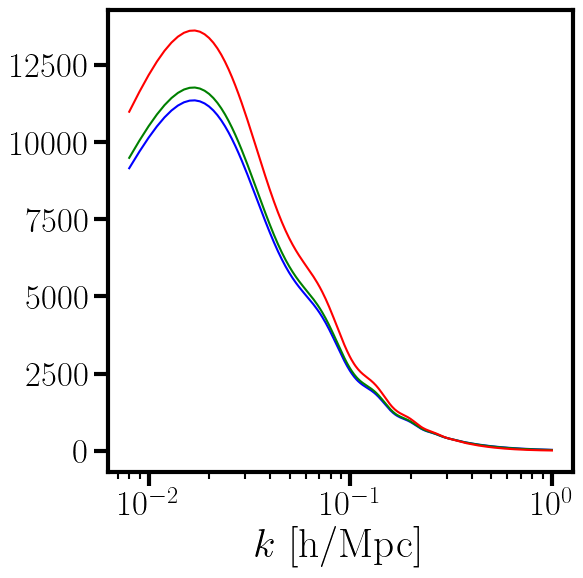

Pgaga_bga_315.txt


<Figure size 640x480 with 0 Axes>

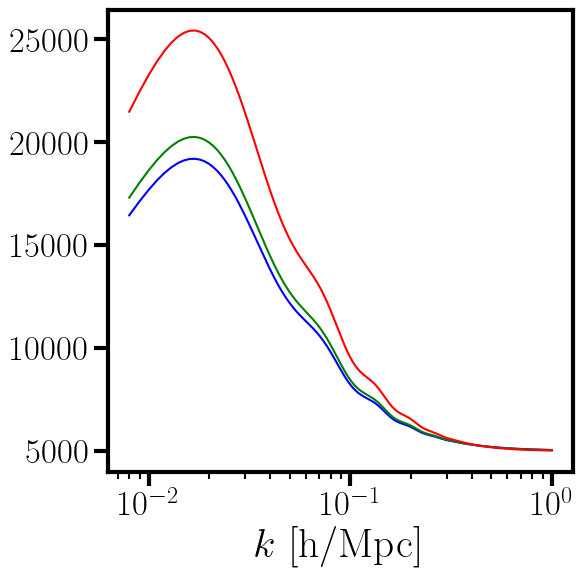

pfid_gaga_315.txt


<Figure size 640x480 with 0 Axes>

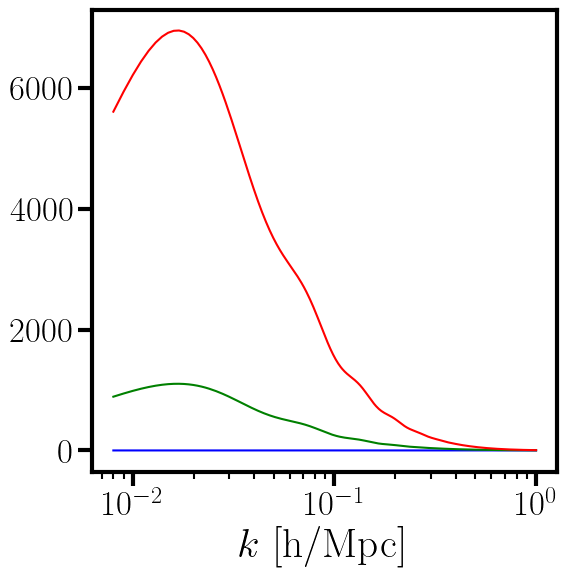

Pgaga_f_315.txt


<Figure size 640x480 with 0 Axes>

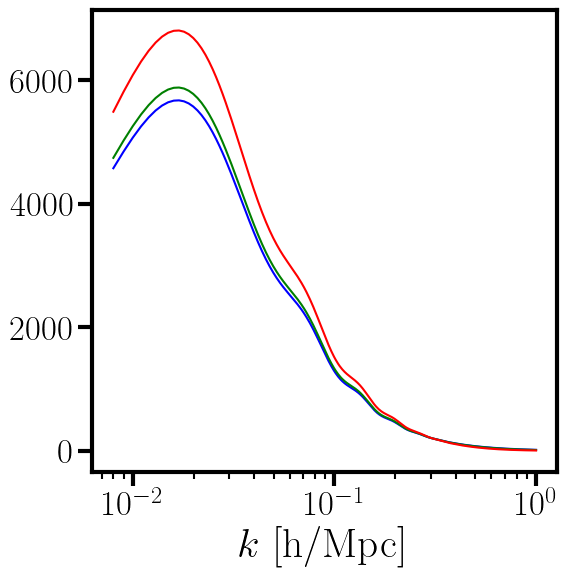

Pgaga_ba_315.txt


<Figure size 640x480 with 0 Axes>

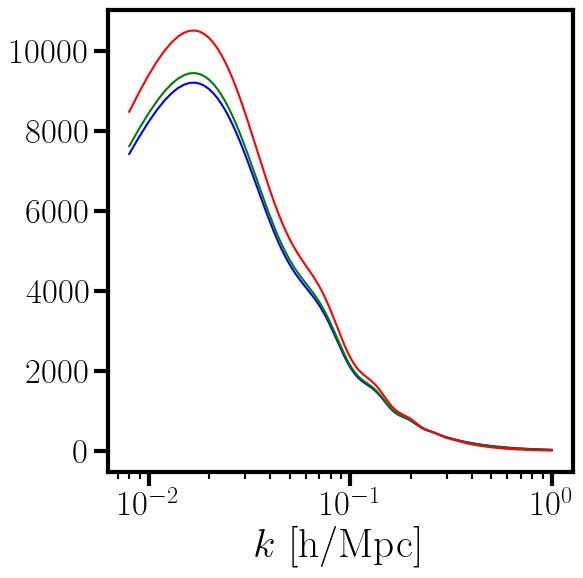

Pgagb_ba_285.txt


<Figure size 640x480 with 0 Axes>

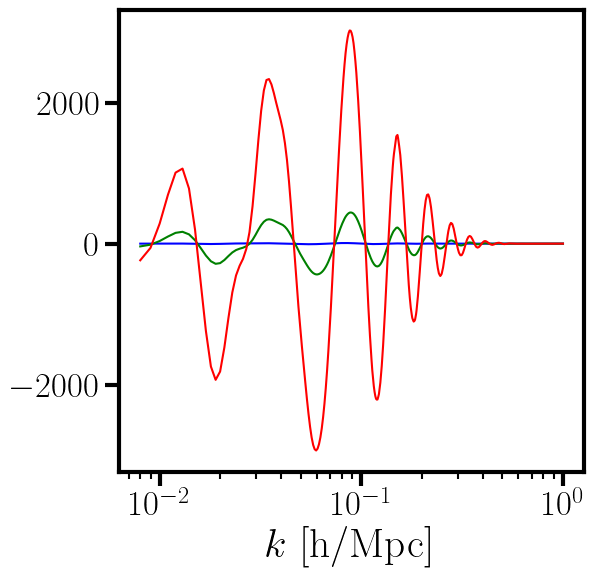

Pgbgb_alpha_parallel_315.txt


<Figure size 640x480 with 0 Axes>

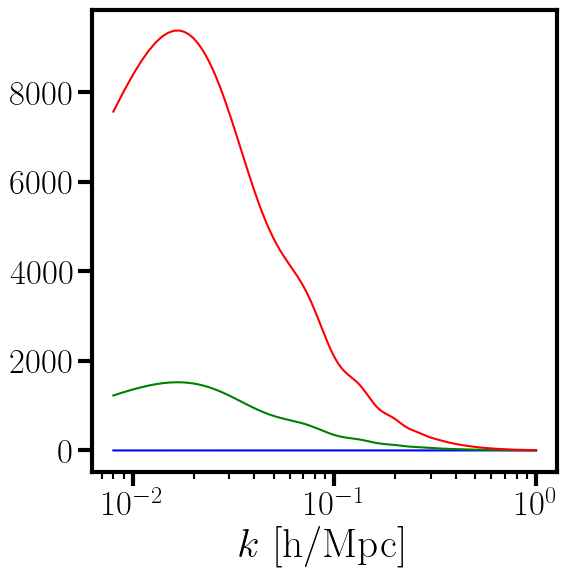

Pgagb_f_285.txt


<Figure size 640x480 with 0 Axes>

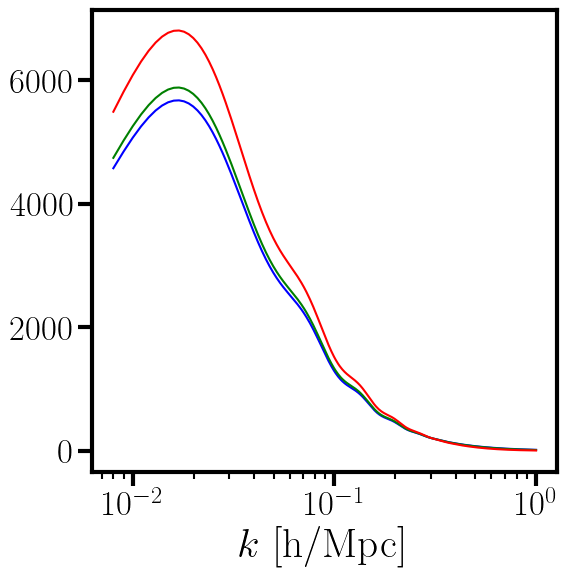

Pgagb_bgb_315.txt


<Figure size 640x480 with 0 Axes>

In [11]:
wsforecast.check_derivatives()